# 🧠 Brain Tumor Detection Using ResNet50 + Grad-CAM
This project builds a binary image classifier using transfer learning with ResNet50 to detect brain tumors from MRI scans. It also integrates Grad-CAM for visual model explainability and provides performance metrics via a confusion matrix and classification report.



# Dataset used:
Brain MRI Images for Brain Tumor Detection: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection?resource=download

# Import librares 

In [1]:


import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2
import matplotlib.pyplot as plt



In [2]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
data_dir = 'C:\\Users\\maram\\Downloads\\New folder\\archive\\brain_tumor_dataset'
batch_size = 16
image_size = 224
epochs = 15
learning_rate = 0.001


# Transforms with data augmentation

In [4]:


transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
full_dataset = datasets.ImageFolder(data_dir, transform=transform)
class_names = full_dataset.classes
targets = [label for _, label in full_dataset.imgs]



# Stratified split

In [5]:

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(np.zeros(len(targets)), targets))
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)



# Calculate class weights for imbalance

In [6]:

labels = [full_dataset.targets[i] for i in train_idx]
pos_weight = torch.tensor([labels.count(0) / labels.count(1)]).to(device)

# Model: ResNet50 with modified final layer

In [7]:

model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze all layers

model.fc = nn.Linear(model.fc.in_features, 1)  # Binary classification
model.fc.requires_grad = True  # fine-tune last FC layer
model = model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

C:\Users\maram\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\maram\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Training loop

In [8]:
# Training loop
print("Training started...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

    # Unfreeze after a few epochs for fine-tuning
    if epoch == 4:
        for param in model.parameters():
            param.requires_grad = True



Training started...
Epoch 1/15, Loss: 0.4858
Epoch 2/15, Loss: 0.4243
Epoch 3/15, Loss: 0.3655
Epoch 4/15, Loss: 0.3392
Epoch 5/15, Loss: 0.3498
Epoch 6/15, Loss: 0.2866
Epoch 7/15, Loss: 0.1518
Epoch 8/15, Loss: 0.0748
Epoch 9/15, Loss: 0.0709
Epoch 10/15, Loss: 0.0331
Epoch 11/15, Loss: 0.0268
Epoch 12/15, Loss: 0.0436
Epoch 13/15, Loss: 0.0086
Epoch 14/15, Loss: 0.0169
Epoch 15/15, Loss: 0.0143


# Evaluation

In [9]:

print("\nEvaluating model...")
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        y_pred.extend(preds.astype(int).flatten().tolist())
        y_true.extend(labels.numpy().flatten().tolist())

print(classification_report(y_true, y_pred, target_names=class_names))



Evaluating model...
              precision    recall  f1-score   support

          no       0.89      0.85      0.87        20
         yes       0.91      0.94      0.92        31

    accuracy                           0.90        51
   macro avg       0.90      0.89      0.90        51
weighted avg       0.90      0.90      0.90        51



# Confusion matrix

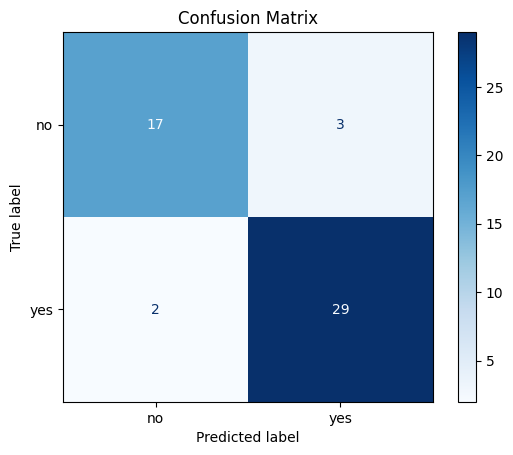

In [10]:

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Grad-CAM Visualization


Generating Grad-CAM...


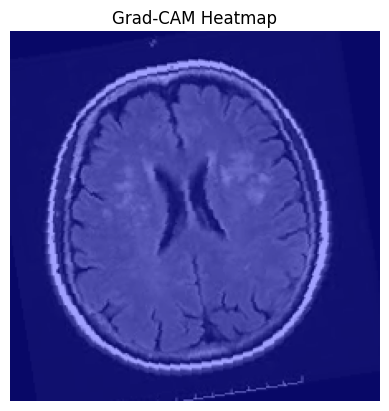

In [11]:

print("\nGenerating Grad-CAM...")
input_tensor = next(iter(test_loader))[0][0].unsqueeze(0).to(device)
original_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
original_img = np.clip((original_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]), 0, 1)

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor)[0, :]
visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()